
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



<div style="border: 2px solid blue; padding: 10px; border-radius: 5px;">
Hi Ryan,

My name is Mixo (https://hub.tripleten.com/u/290771b5). 
Congratulations on submitting your practical project! 🎉 Breaking into the world of data can feel challenging at first, but it’s also an exciting and highly rewarding journey. I am excited to help guide you through this journey!

Final Decision: Approved ✅

Excellent work!

You’ve successfully met all project requirements, and your implementation demonstrates a solid understanding of the key concepts.

You can find my more detailed notes within your project notebook in the Reviewer's comment v2: section.

You’ll see my comments highlighted in colored boxes:

<div class="alert alert-block alert-success">
🟢 Green → Success. Everything is correct.
</div>

<div class="alert alert-block alert-warning">
🟡 Yellow → Recommendations. Improvements suggested.
</div>
<div class="alert alert-block alert-danger">
🔴 Red → Requires fixing. Changes are necessary before approval.
</div>

<div style="border: 2px solid green; padding: 10px; border-radius: 5px;">
Your project is done very well! Cogratulations on the great work. Just some minor tweaks will make sure your project is optimal.

**Strengths**

- Date columns were correctly converted and monthly features were added.
- The rounding rule for call duration was properly implemented before aggregation.
- The exploratory comparisons between plan groups are clearly described.


</div>

Your project is approved. Keep up the great work — you’re making strong progress.

Congratulations!

# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

## Initialization

Import all necessary libraries for data analysis, including pandas, numpy, scipy, math, and matplotlib.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This section would benefit from a brief project roadmap: summarize the main data-prep steps (type fixes/rounding rules), how you’ll aggregate to user-month level, how revenue will be computed, and which hypotheses you’ll test. A short plan here makes the rest of the notebook much easier to follow.

</div>


In [1]:
# Loading all the libraries
import pandas as pd
import numpy as np
from scipy import stats as st # for hypothesis testing
import math # for rounding
import matplotlib.pyplot as plt # plots
print(pd.__version__) #testing issues with xlabel and ylabel assignment in .plot()

1.2.4


## Load data

Load the five Megaline datasets (calls, internet, messages, plans, users) from CSV files into separate DataFrames for exploration and analysis.

In [2]:
# Load the data files into different DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare the data

## Plans

In [3]:
# Print the general/summary information about the plans' DataFrame
print("plans DataFrame titles:", plans.columns.tolist()) # Print all column titles as a Python list
print("plans DataFrame shape:", plans.shape)
plans.describe() # .describe() may not be all that useful for this DataFrame

plans DataFrame titles: ['messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name']
plans DataFrame shape: (2, 8)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000
mean,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
std,671.751442,10861.160159,1767.766953,35.355339,2.12132,0.014142,0.014142
min,50.000000,15360.000000,500.000000,20.000000,7.00000,0.010000,0.010000
25%,287.500000,19200.000000,1125.000000,32.500000,7.75000,0.015000,0.015000
50%,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
75%,762.500000,26880.000000,2375.000000,57.500000,9.25000,0.025000,0.025000
max,1000.000000,30720.000000,3000.000000,70.000000,10.00000,0.030000,0.030000


In [4]:
# Print a sample of data for plans
plans.info(show_counts=True)
plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


This DataFrame, 'plans', is short. The purpose of this DataFrame is to tabulate the parameters associated with the two core Megaline plans being analyzed in the subject Statistical Data Analysis project. All associated data types check out as correct on the source data, and there are no apparent data entry errors.

It may be useful to add a gb_per_month_included to account for the conversion 1 GB = 1024 MB but the usefulness of this operation remains to be seen at this stage of the project.

## Fix Data

No data fixes were needed for the `plans` DataFrame.

## Enrich Data

In [5]:
#For 'plans': N/A

## Users

In [6]:
# Print the general/summary information about the users' DataFrame
print("users DataFrame titles:", users.columns.tolist())  # Print all column titles as a Python list
print("users DataFrame shape:", users.shape)
users.describe()

users DataFrame titles: ['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date']
users DataFrame shape: (500, 8)


,user_id,age
count,500.000000,500.000000
mean,1249.500000,45.486000
std,144.481833,16.972269
min,1000.000000,18.000000
25%,1124.750000,30.000000
50%,1249.500000,46.000000
75%,1374.250000,61.000000
max,1499.000000,75.000000


In [7]:
# Print a sample of data for users
users.info(show_counts=True)
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN



Looking at the 'users' DataFrame, there are several points of interest. The data types for user_id and age are correct, as int64 is suited for sets of whole number which do not contain any null values. data types of first_name, last_name, city, and plan are all acceptable as objects as well. However, reg_date and churn_date are stored as objects, likely composed of underlying strings/tuples, when they are dates which are better expressed with the datetime data type. Correction of object dates to datetime dates will be important for future operations as the datetime data type is optimal for making date calculations easier, chronological sorting, and time-based filtering/analysis. Additionally, churn_date has NaN values that must be handled in future operations but no effort should be expended to correct them now. The churn_date NaN values represent the end of a chronological period which has not closed. In this case, reg_date to churn_date in the case of churn_date NaN values is equivalent to saying reg_date to "Present".

Furthermore, there is a data quality issue visible from Excel. The city column of 'users' has data containing mojibake corruption. This has the potential to negatively impact my analysis, as I am required to test a statistical hypothesis with city (location) as a parameter. The root cause of the problem is a discrepancy in character allocation for dashes (short - vs long –). After using users.head(50) it has become apparent that the corrupted character is the long dash – separator when read out in Excel. As the character/corruption is only in relation to a kind of delimiter, my judgement is that this observation will not impact my future data analysis operations, as filtration of the city column would revolve around like groups of strings (duplicates) or significant text in substrings (state only, city only, etc.). Therefore, I am not going to write an algorithm to correct this feature of the source data.


### Fix Data

In [8]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT


### Enrich Data

In [9]:
#For 'users': N/A

## Calls

In [10]:
# Print the general/summary information about the calls' DataFrame
print("calls DataFrame titles:", calls.columns.tolist())  # Print all column titles as a Python list
print("calls DataFrame shape:", calls.shape)
calls.describe()

calls DataFrame titles: ['id', 'user_id', 'call_date', 'duration']
calls DataFrame shape: (137735, 4)


,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000


In [11]:
# Print a sample of data for calls
calls.info(show_counts=True)
calls.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22



Looking at the 'calls' DataFrame, there are several notes. The data types for id, user_id and duration are correct. On the subject of 'duration', the float data will have to be rounded and converted to an integer for subsequent analysis, so enriching the data with an additional column of administrative_duration rounded up to the nearest minute adds value. The data type for call_date is stored as an object when they are better expressed with the datetime data type. Correction of object dates to datetime dates will be important for future operations as the datetime data type is optimal for making date calculations easier, chronological sorting, and time-based filtering/analysis. No null data exists in any column, which confirms a complete dataset. Checking the dataset for value corruption would have to be conducted with several function passes to check for different kinds of anomalies, but there is no reason to believe that any element of this dataset harbors anomalies that will negatively impact subsequent analysis. A cursory, manual scrollthrough of the Excel counterpart of this DataFrame confirms my conclusion. Also, the 'calls' DataFrame can be enriched with 'month' data to make operating with 'call_date' easier in subsequent analysis.

Furthermore, the 'id' column tabulates calls per user. However, the log kept for each user is incomplete, as certain 'id' numbers such as the initial user_id = 1000 only have some of their numerically sequenced call log recorded, rather than having a cleanly indexed and numerically complete set (i.e. 1, 2, 3, 4, etc.). Thus, if directly evaluating the call activity of two or more individual users, the sample set size of each id subset must be accounted for, as user call activity tabulated in 'id' is neither completely logged nor uniform from user to user.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your interpretation of the call/message/session `id` suffixes as an “incomplete log” is misleading for this dataset. These `id` values are identifiers, not an expected per-user sequence, so gaps don’t indicate missing records—focus on usage counts/sums and checks for actual missing rows/duplicates instead.

</div>


In [12]:
# Brief function to visualize 'id'
user_1000_calls = calls[calls['user_id'] == 1000]['id'].head(100)
print(user_1000_calls)

0      1000_93
1     1000_145
2     1000_247
3     1000_309
4     1000_380
5     1000_388
6     1000_510
7     1000_521
8     1000_530
9     1000_544
10    1000_693
11    1000_705
12    1000_735
13    1000_778
14    1000_826
15    1000_842
Name: id, dtype: object


### Fix Data

In [13]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

### Enrich Data

In [14]:
calls['month'] = (calls['call_date']).dt.month
calls['administrative_duration'] = calls['duration'].apply(np.ceil).astype('Int64') # np.ceil() can be applied to DataFrames, and holds floating 0s at the integer instead of pushing the value up a full +1
calls.info()
calls.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   id                       137735 non-null  object        
 1   user_id                  137735 non-null  int64         
 2   call_date                137735 non-null  datetime64[ns]
 3   duration                 137735 non-null  float64       
 4   month                    137735 non-null  int64         
 5   administrative_duration  137735 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 6.4+ MB


,id,user_id,call_date,duration,month,administrative_duration
0,1000_93,1000,2018-12-27,8.52,12,9
1,1000_145,1000,2018-12-27,13.66,12,14
2,1000_247,1000,2018-12-27,14.48,12,15
3,1000_309,1000,2018-12-28,5.76,12,6
4,1000_380,1000,2018-12-30,4.22,12,5


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Good work converting dates to datetime, adding a `month` feature, and applying the correct rounding rule (round each call up before monthly aggregation). These details are essential for accurate monthly usage and revenue calculations.

</div>


## Messages

In [15]:
# Print the general/summary information about the messages' DataFrame
print("messages DataFrame titles:", messages.columns.tolist())  # Print all column titles as a Python list
print("messages DataFrame shape:", messages.shape)
messages.describe()

messages DataFrame titles: ['id', 'user_id', 'message_date']
messages DataFrame shape: (76051, 3)


,user_id
count,76051.000000
mean,1245.972768
std,139.843635
min,1000.000000
25%,1123.000000
50%,1251.000000
75%,1362.000000
max,1497.000000


In [16]:
# Print a sample of data for messages
messages.info(show_counts=True)
messages.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26



Looking at the 'messages' DataFrame, there are a few notes. No null values are present, thus confirming a complete dataset. Columns 'id' and 'user_id' are correct and match previously established data types. The data type for 'message_date' is stored as an object when they are better expressed with the datetime data type. Also, the 'messages' DataFrame can be enriched with 'month' data to make operating with 'message_date' easier in subsequent analysis.

Furthermore, the 'id' column tabulates messages per user. However, the log kept for each user is incomplete, as certain 'id' numbers such as the initial user_id = 1000 only have some of their numerically sequenced message log recorded, rather than having a cleanly indexed and numerically complete set (i.e. 1, 2, 3, 4, etc.). A cursory, manual scrollthrough of the Excel counterpart of this DataFrame confirms this claim. Thus, if directly evaluating the message activity of two or more individual users, the sample set size of each id subset must be accounted for, as user message activity tabulated in 'id' is neither completely logged nor uniform from user to user.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recurring note: as mentioned earlier, non-sequential `id` values per user don’t imply missing message records—treat `id` as an identifier rather than a counter.

</div>


### Fix Data

In [17]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

### Enrich Data

In [18]:
messages['month'] = (messages['message_date']).dt.month
messages.info()
messages.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 2.3+ MB


,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


## Internet

In [19]:
# Print the general/summary information about the internet DataFrame
print("internet DataFrame titles:", internet.columns.tolist())  # Print all column titles as a Python list
print("internet DataFrame shape:", internet.shape)
internet.describe()

internet DataFrame titles: ['id', 'user_id', 'session_date', 'mb_used']
internet DataFrame shape: (104825, 4)


,user_id,mb_used
count,104825.000000,104825.000000
mean,1242.496361,366.713701
std,142.053913,277.170542
min,1000.000000,0.000000
25%,1122.000000,136.080000
50%,1236.000000,343.980000
75%,1367.000000,554.610000
max,1499.000000,1693.470000


In [20]:
# Print a sample of data for the internet traffic
internet.info(show_counts=True)
internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Looking at the 'internet' DataFrame, there are a few notes. No null values are present, thus confirming a complete dataset. Columns 'id' and 'user_id' are correct and match previously established data types. The data type for 'session_date' is stored as an object when they are better expressed with the datetime data type. The 'mb_used' column data type is appropriate for now, as 'mb_used' will be used to sum per-month usage before being rounded up to the nearest GB in subsequent operations. Also, the 'internet' DataFrame can be enriched with 'month' data to make operating with 'session_date' easier in subsequent analysis.

Furthermore, the 'id' column tabulates sessions per user. However, the log kept for each user is incomplete, as certain 'id' numbers such as the initial user_id = 1000 only have some of their numerically sequenced session log recorded, rather than having a cleanly indexed and numerically complete set (i.e. 1, 2, 3, 4, etc.). A cursory, manual scrollthrough of the Excel counterpart of this DataFrame confirms this claim. Thus, if directly evaluating the session activity of two or more individual users, the sample set size of each id subset must be accounted for, as user session activity tabulated in 'id' is neither completely logged nor uniform from user to user.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recurring note: as mentioned earlier, non-sequential `id` values per user don’t imply missing session records—avoid treating `id` gaps as a data-quality issue without evidence of dropped rows/duplicates.

</div>


### Fix Data

In [21]:
internet['session_date'] = pd.to_datetime(internet['session_date'])

### Enrich Data

In [22]:
internet['month'] = (internet['session_date']).dt.month
internet.info()
internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 4.0+ MB


,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


## Study plan conditions

In [23]:
# Print out the plan conditions and make sure they are clear for you
plans # print(plans) converts the DataFrame to a string representation which can alter formatting cleanliness

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Aggregate data per user

[Now, as the data is clean, aggregate data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.]

In [24]:
# Calculate the number of calls made by each user per month. Save the result.
calls_per_user_monthly = calls.groupby(['user_id', 'month'])['id'].count()
calls_per_user_monthly = calls_per_user_monthly.reset_index() # Dot code recommendation - cleanup boilerplate
calls_per_user_monthly.columns = ['user_id', 'month', 'calls_count'] # Dot code recommendation - the raw variable makes intuitive sense but can cause problems with index processing later without this cleanup
calls_per_user_monthly.head()

,user_id,month,calls_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [25]:
# Calculate the amount of minutes spent by each user per month. Save the result.
minutes_per_user_monthly = calls.groupby(['user_id', 'month'])['administrative_duration'].sum()
minutes_per_user_monthly = minutes_per_user_monthly.reset_index()
minutes_per_user_monthly.columns = ['user_id', 'month', 'administrative_duration_monthly_sum']
minutes_per_user_monthly.head()

,user_id,month,administrative_duration_monthly_sum
0,1000,12,124
1,1001,8,182
2,1001,9,315
3,1001,10,393
4,1001,11,426


In [26]:
# .agg() method for the same operation in the cell above
# Semicolon at the end of tripled comments hide the string from the cell output
"""
# Instead of separate operations, you can do both count and sum in one go
calls_summary = calls.groupby(['user_id', 'month']).agg({
    'id': 'count',  # Count of calls
    'administrative_duration': 'sum'  # Sum of minutes
}).reset_index()

# Rename columns for clarity
calls_summary.columns = ['user_id', 'month', 'calls_count', 'total_minutes']
""";
# and:
"""
# Multiple aggregations on the same column
calls_detailed = calls.groupby(['user_id', 'month']).agg({
    'administrative_duration': ['sum', 'mean', 'count']
}).reset_index()
""";

In [27]:
# Calculate the number of messages sent by each user per month. Save the result.
messages_per_user_monthly = messages.groupby(['user_id', 'month'])['id'].count()
messages_per_user_monthly = messages_per_user_monthly.reset_index()
messages_per_user_monthly.columns = ['user_id', 'month', 'messages_count_monthly']
messages_per_user_monthly.head()

,user_id,month,messages_count_monthly
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [28]:
# Calculate the volume of internet traffic used by each user per month. Save the result.
internet_per_user_monthly = internet.groupby(['user_id', 'month'])['mb_used'].sum() # internet_per_user = "session_use"
internet_per_user_monthly = internet_per_user_monthly.reset_index()
internet_per_user_monthly.columns = ['user_id', 'month', 'mb_used_monthly_sum']
internet_per_user_monthly['administrative_gb_used_monthly_sum'] = ((internet_per_user_monthly['mb_used_monthly_sum']
                                                           )/1024).apply(np.ceil).astype('Int64') # Rounding data usage
internet_per_user_monthly.head()

,user_id,month,mb_used_monthly_sum,administrative_gb_used_monthly_sum
0,1000,12,1901.47,2
1,1001,8,6919.15,7
2,1001,9,13314.82,14
3,1001,10,22330.49,22
4,1001,11,18504.30,19


In [29]:
# Merge the data for calls, minutes, messages, internet based on user_id and month
user_stats_monthly = pd.merge(calls_per_user_monthly,
                              minutes_per_user_monthly,
                              on=['user_id', 'month'], 
                              how='outer'
    )

user_stats_monthly = pd.merge(user_stats_monthly, 
                              messages_per_user_monthly,
                              on=['user_id', 'month'], 
                              how='outer'
    )
    
user_stats_monthly = pd.merge(user_stats_monthly, 
                              internet_per_user_monthly,
                              on=['user_id', 'month'], 
                              how='outer'
    )
user_stats_monthly = user_stats_monthly.fillna(0)
user_stats_monthly
# Could have written a loop or a lambda function but chose not to. I would write one if there were more merges to be done. This is readable.
# Could also remove the mb_used_monthly_sum since I got the administrative GB data already.
# Changed from how='inner' to how='outer' for dataset safety. Inner drops any user-month where the user had activity in SOME categories but not ALL. Outer does not cut values, but may create NaN values during misaligned merges.
# Now, this merging strategy is capturing all possible user-month combinations where users had ANY activity.

,user_id,month,calls_count,administrative_duration_monthly_sum,messages_count_monthly,mb_used_monthly_sum,administrative_gb_used_monthly_sum
0,1000,12,16.0,124,11.0,1901.47,2
1,1001,8,27.0,182,30.0,6919.15,7
2,1001,9,49.0,315,44.0,13314.82,14
3,1001,10,65.0,393,53.0,22330.49,22
4,1001,11,64.0,426,36.0,18504.30,19
...,...,...,...,...,...,...,...
2288,1349,12,0.0,0,61.0,13039.91,13
2289,1361,5,0.0,0,2.0,1519.69,2
2290,1482,10,0.0,0,2.0,0.00,0
2291,1108,12,0.0,0,0.0,233.17,1


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Be careful with `fillna(0)` after the outer merges. It can (1) turn count columns into floats and (2) create user-month rows that didn’t really exist (months where a user had no records in any source table), which can distort analysis and later revenue charging. Consider filling NaNs only for the specific usage columns, converting counts/minutes/GB back to integer types where appropriate, and ensuring you’re only keeping valid user-months (e.g., those present in the data or built from an explicit user-month calendar) before computing revenue.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Great job using the outer merge and filling in the missing values with zero 0!
</div>



In [30]:
# Add the plan information
user_stats_monthly = pd.merge(user_stats_monthly, 
                              users[['user_id', 'plan']],
                              on=['user_id'], 
                              how='inner'
    ) # Plan data exists for every user, so how='inner' is safe here.
user_stats_monthly

,user_id,month,calls_count,administrative_duration_monthly_sum,messages_count_monthly,mb_used_monthly_sum,administrative_gb_used_monthly_sum,plan
0,1000,12,16.0,124,11.0,1901.47,2,ultimate
1,1001,8,27.0,182,30.0,6919.15,7,surf
2,1001,9,49.0,315,44.0,13314.82,14,surf
3,1001,10,65.0,393,53.0,22330.49,22,surf
4,1001,11,64.0,426,36.0,18504.30,19,surf
...,...,...,...,...,...,...,...,...
2288,1204,12,0.0,0,78.0,36730.05,36,ultimate
2289,1349,10,0.0,0,76.0,13093.55,13,surf
2290,1349,11,0.0,0,72.0,17128.26,17,surf
2291,1349,12,0.0,0,61.0,13039.91,13,surf


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice approach merging activity with `how='outer'` and then joining plan info from `users`. Preserving months where a customer used only one service is important for fair behavior and revenue comparisons.

</div>


In [31]:
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [32]:
# Calculate the monthly revenue for each user

# Calculate overage for each usage category
# np.maximum() compares two values: 0 and (usage - limit) and returns the larger of the two to control for negative (usage - limit) results

# Overage minutes
user_stats_monthly['overage_minutes'] = np.where(
      user_stats_monthly['plan'] == 'surf',
      np.maximum(0, user_stats_monthly['administrative_duration_monthly_sum'] - 500),
      np.maximum(0, user_stats_monthly['administrative_duration_monthly_sum'] - 3000)
  )

# Overage messages
user_stats_monthly['overage_messages'] = np.where(
      user_stats_monthly['plan'] == 'surf',
      np.maximum(0, user_stats_monthly['messages_count_monthly'] - 50),
      np.maximum(0, user_stats_monthly['messages_count_monthly'] - 1000)
  )

# Overage GB
user_stats_monthly['overage_gb'] = np.where(
      user_stats_monthly['plan'] == 'surf',
      np.maximum(0, user_stats_monthly['administrative_gb_used_monthly_sum'] - 15), #Converting MB to GB for the constant
      np.maximum(0, user_stats_monthly['administrative_gb_used_monthly_sum'] - 30)
  )

# Calculate total monthly revenue
user_stats_monthly['revenue'] = np.where(
      user_stats_monthly['plan'] == 'surf', # Condition
    
      20 + (user_stats_monthly['overage_minutes'] * 0.03) # if True
         + (user_stats_monthly['overage_messages'] * 0.03)
         + (user_stats_monthly['overage_gb'] * 10),
    
      70 + (user_stats_monthly['overage_minutes'] * 0.01) # if False
         + (user_stats_monthly['overage_messages'] * 0.01)
         + (user_stats_monthly['overage_gb'] * 7)
  )
user_stats_monthly.head(10)

,user_id,month,calls_count,administrative_duration_monthly_sum,messages_count_monthly,mb_used_monthly_sum,administrative_gb_used_monthly_sum,plan,overage_minutes,overage_messages,overage_gb,revenue
0,1000,12,16.0,124,11.0,1901.47,2,ultimate,0,0.0,0,70.0
1,1001,8,27.0,182,30.0,6919.15,7,surf,0,0.0,0,20.0
2,1001,9,49.0,315,44.0,13314.82,14,surf,0,0.0,0,20.0
3,1001,10,65.0,393,53.0,22330.49,22,surf,0,3.0,7,90.09
4,1001,11,64.0,426,36.0,18504.30,19,surf,0,0.0,4,60.0
5,1001,12,56.0,412,44.0,19369.18,19,surf,0,0.0,4,60.0
6,1002,10,11.0,59,15.0,6552.01,7,surf,0,0.0,0,20.0
7,1002,11,55.0,386,32.0,19345.08,19,surf,0,0.0,4,60.0
8,1002,12,47.0,384,41.0,14396.24,15,surf,0,0.0,0,20.0
9,1003,12,149.0,1104,50.0,27044.14,27,surf,604,0.0,12,158.12


### Calls

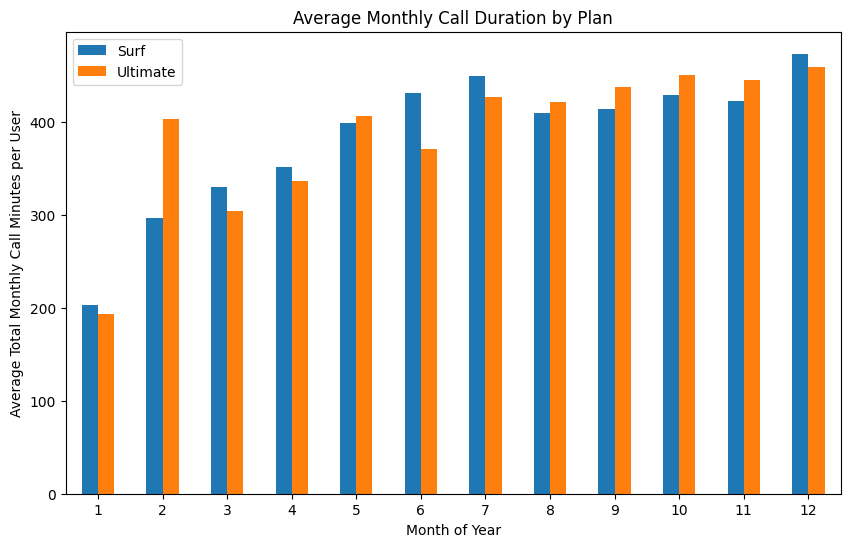

In [33]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plat to visualize it.

# Strip out user monthly stat data sorted by plan type
surf_data = user_stats_monthly[user_stats_monthly['plan'] == 'surf']
ultimate_data = user_stats_monthly[user_stats_monthly['plan'] == 'ultimate']

# Find arithmetic mean of plan-typed datasets, using month buckets via .groupby()
surf_avg_duration = surf_data.groupby('month')['administrative_duration_monthly_sum'].mean()
ultimate_avg_duration = ultimate_data.groupby('month')['administrative_duration_monthly_sum'].mean()

# Concat new DataFrame on the x-axis to seat the Series objects next to each other
avg_duration_by_plan = pd.concat([surf_avg_duration, ultimate_avg_duration], axis=1)
avg_duration_by_plan.columns = ['Surf', 'Ultimate']

avg_duration_by_plan.plot(kind='bar', 
                          title='Average Monthly Call Duration by Plan', 
                          figsize=(10, 6),
                          xlabel='Month of Year',
                          ylabel='Average Total Monthly Call Minutes per User',
                          legend=True,
                          rot=0
    )
plt.show()

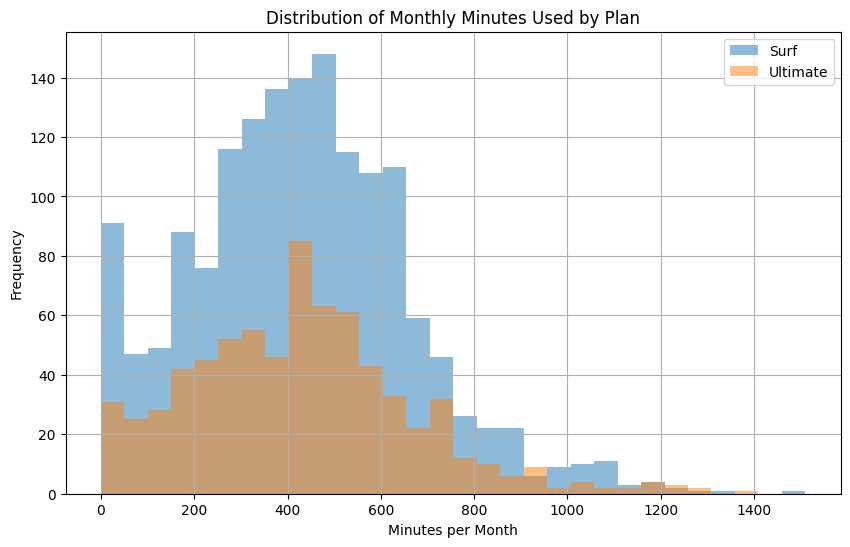

In [34]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.
duration_by_plan = pd.concat([surf_data['administrative_duration_monthly_sum'], ultimate_data['administrative_duration_monthly_sum']], axis=1)
duration_by_plan.columns = ['Surf', 'Ultimate']
duration_by_plan.plot(kind='hist',
                      bins=30, # Each bin spans 50 minutes
                      alpha=0.5,
                      figsize=(10, 6), 
                      grid=True, 
                      legend=True, 
                      title='Distribution of Monthly Minutes Used by Plan' 
    )
plt.xlabel('Minutes per Month') # Compatibility issue, xlabel does not display normally when in the argument definition list of the main .plot() method
plt.ylabel('Frequency')
plt.show()

"""
Rationale for DataFrame concat graphing instead of overlaying plan datasets individually with multiple .plot()

Both plans use identical bin boundaries calculated from the combined data range, ensuring:
- Fair comparison: Same measurement intervals for both plans
- Accurate pattern detection: True differences in usage behavior
- Reliable business insights: Better foundation for revenue analysis
""";

In [35]:
# Calculate the mean and the variance of the monthly call duration
print('Surf Plan')
print('Mean monthly minutes:', surf_data['administrative_duration_monthly_sum'].mean())
print('Variance of monthly minutes:', surf_data['administrative_duration_monthly_sum'].var())
print('Std dev of monthly minutes:', surf_data['administrative_duration_monthly_sum'].std())
print()
print('Ultimate Plan')
print('Mean monthly minutes:', ultimate_data['administrative_duration_monthly_sum'].mean())
print('Variance of monthly minutes:', ultimate_data['administrative_duration_monthly_sum'].var())
print('Std dev of monthly minutes:', ultimate_data['administrative_duration_monthly_sum'].std())
# No reason to implement sigfigs. These are calculated values that are not reliant on a precision standard.

Surf Plan
Mean monthly minutes: 428.7495232040687
Variance of monthly minutes: 54968.27946065038
Std dev of monthly minutes: 234.4531498202794

Ultimate Plan
Mean monthly minutes: 430.45
Variance of monthly minutes: 57844.464812239225
Std dev of monthly minutes: 240.5087624437813


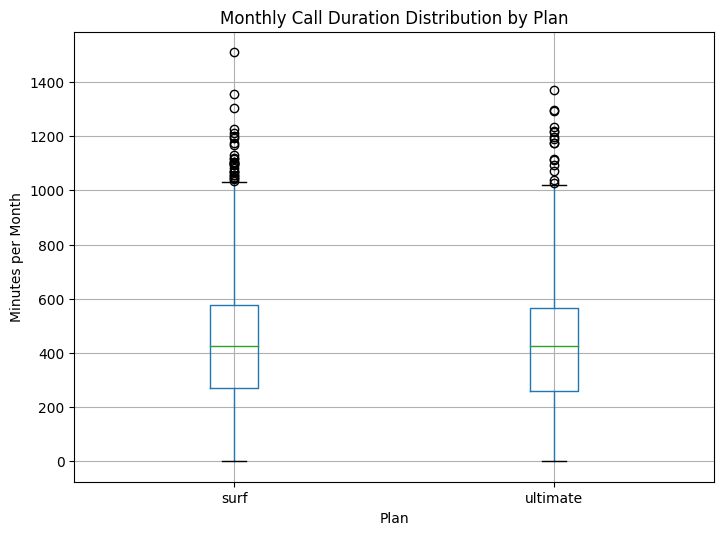

In [36]:
# Plot a boxplot to visualize the distribution of the monthly call duration
user_stats_monthly.boxplot(column='administrative_duration_monthly_sum', by='plan', figsize=(8, 6))
plt.title('Monthly Call Duration Distribution by Plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Minutes per Month')
plt.show()
# Box = IQR (25th to 75th percentile), line = median, whiskers extend to 1.5*IQR, dots beyond = outliers

**Conclusions on how the users behave in terms of calling relative to plans chosen**

Both Surf and Ultimate users show similar calling patterns, with distributions centered around comparable values. The difference in user behavior in terms of monthly calling is slight relative to the plans chosen. 

It is true that Surf users tend to use a few minutes less on average compared to Ultimate users. The histogram shows that Surf users cluster at lower minute values while Ultimate users have a wider spread. The variance and standard deviation confirm that Ultimate users exhibit more variability in their calling behavior. The boxplot reveals that both plans have outliers on the high end, but Surf users generally stay well within their 500-minute allowance while Ultimate users, despite having a much higher 3000-minute limit, also tend to use only a moderate portion of their included minutes. Also, it is clear that there are fewer Ultimate users than Surf users, as is to be expected, as not everyone expects themselves to be a power user of the service. Overall, calling behavior does differ between the plans: Ultimate users call more on average and with greater variability, but only by very slight margins. 

With consideration given to the potential statistical significance of the differences in user monthly calling behavior relative to the plans chosen, one could rule that there is no significant difference in the behavior either plans' users.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This conclusions paragraph is in the Calls section, but it refers to “messaging patterns.” Consider revising the wording to consistently discuss call minutes/duration so the narrative matches the analysis and plots above.

</div>


### Messages

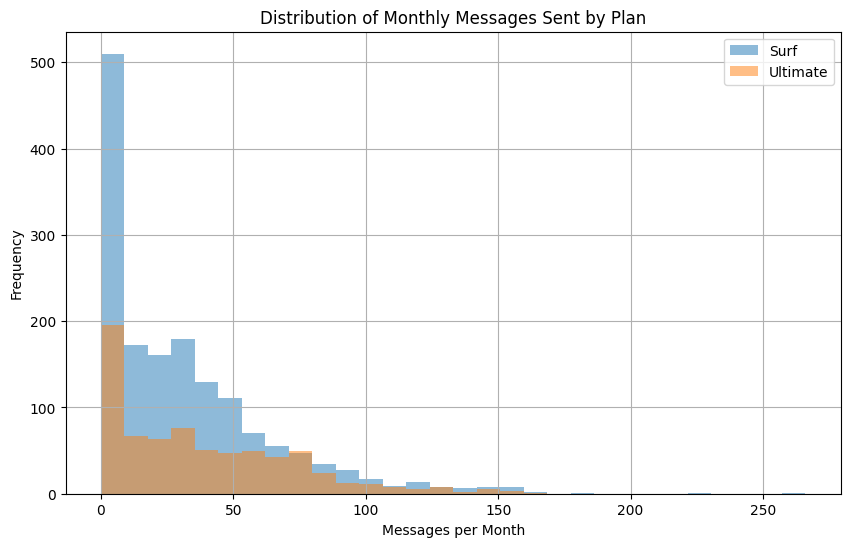

In [37]:
# Compare the number of messages users of each plan tend to send each month
messages_by_plan = pd.concat([surf_data['messages_count_monthly'], ultimate_data['messages_count_monthly']], axis=1)
messages_by_plan.columns = ['Surf', 'Ultimate']
messages_by_plan.plot(kind='hist',
                         bins=30,
                         alpha=0.5,
                         figsize=(10, 6),
                         grid=True,
                         legend=True,
                         title='Distribution of Monthly Messages Sent by Plan'
    )
plt.xlabel('Messages per Month') # Compatibility issue, xlabel does not display normally when in the argument definition list of the main .plot() method
plt.ylabel('Frequency')
plt.show()

In [38]:
# Calculate the mean and the variance of monthly messages
print('Surf Plan')
print('Mean monthly messages:', surf_data['messages_count_monthly'].mean())
print('Variance of monthly messages:', surf_data['messages_count_monthly'].var())
print('Std dev of monthly messages:', surf_data['messages_count_monthly'].std())
print()
print('Ultimate Plan')
print('Mean monthly messages:', ultimate_data['messages_count_monthly'].mean())
print('Variance of monthly messages:', ultimate_data['messages_count_monthly'].var())
print('Std dev of monthly messages:', ultimate_data['messages_count_monthly'].std())

Surf Plan
Mean monthly messages: 31.15956770502225
Variance of monthly messages: 1126.7245219504066
Std dev of monthly messages: 33.566717473569064

Ultimate Plan
Mean monthly messages: 37.55138888888889
Variance of monthly messages: 1208.7567435481378
Std dev of monthly messages: 34.76717911404573


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The cell text says it compares internet traffic, but the code computes message statistics (mean/variance/std). Consider aligning the label/comment with the actual content, and keep internet statistics in the Internet subsection so each section cleanly matches its metric.

</div>


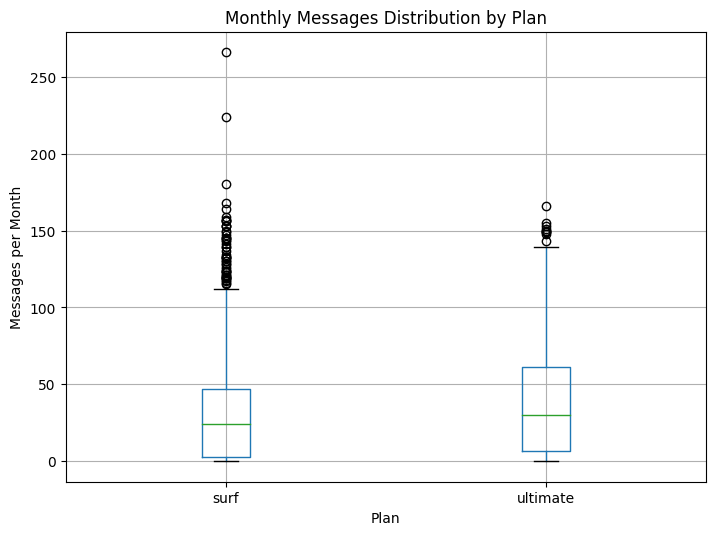

In [39]:
# Boxplot for monthly messages by plan
user_stats_monthly.boxplot(column='messages_count_monthly', by='plan', figsize=(8, 6))
plt.title('Monthly Messages Distribution by Plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Messages per Month')
plt.show()
# Box = IQR (25th to 75th percentile), line = median, whiskers extend to 1.5*IQR, dots beyond = outliers

**Conclusions on how the users behave in terms of messaging relative to plans chosen**

Both Surf and Ultimate users show similar messaging patterns, with distributions centered around comparable values. However, Ultimate users send 6.4 more messages per month on average (37.6 vs 31.2), and this difference appears meaningful given the plan limits. 

Surf users have a 50-message monthly limit, and the data shows many Surf users approach or stay near that threshold. Ultimate users, with a 1000-message limit, rarely come close to exceeding it with a significant subset of Ultimate users only just surpassing the 50-message monthly mark. The variance is moderate for both plans. Messaging behavior is relatively consistent across both plans, with neither group exhibiting dramatically different patterns. The key distinction in user messaging behaviors is that Surf users are more likely to incur overage charges for messages given their much lower included allowance. Again, it is clear that there are fewer Ultimate users than Surf users, as is to be expected, as not everyone expects themselves to be a power user of the service. Many Ultimate users also appear to be susceptible to "premium bloat", where they are willing to overpay for a service that does not reflect their actual needs or behavior due to an overestimation of their need at signup. Many Surf users appear to have the opposite problem with "pennywise poundfoolish" behavior, where they are unwilling to pay for a service that reflects their actual needs or behavior at the cost of overage charges due to an underestimation of their need at signup.

Based on the observed differences in messaging patterns and the relationship to plan limits, there appears to be a meaningful behavioral difference between the two user groups that warrants further statistical testing.

### Internet

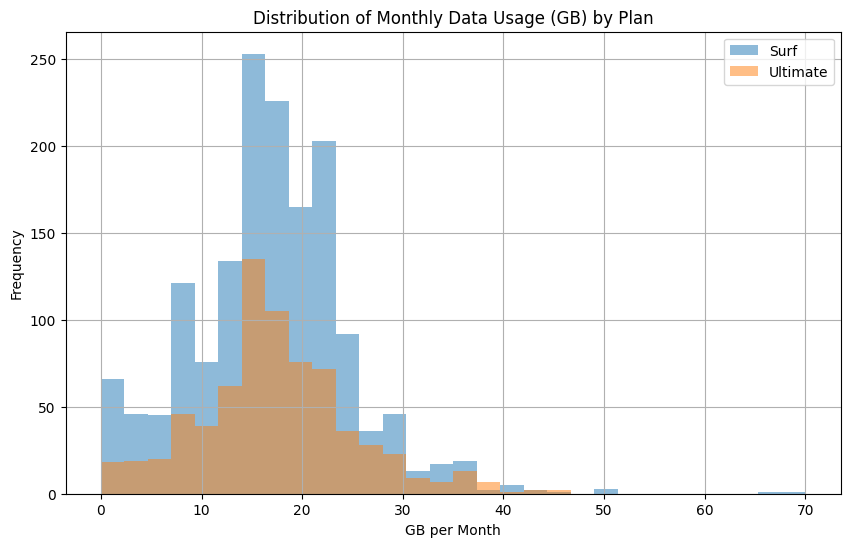

In [40]:
# Compare the volume of internet data consumed by users per plan. Plot a histogram.
internet_by_plan = pd.concat([surf_data['administrative_gb_used_monthly_sum'], ultimate_data['administrative_gb_used_monthly_sum']], axis=1)
internet_by_plan.columns = ['Surf', 'Ultimate']
internet_by_plan.plot(kind='hist',
                         bins=30,
                         alpha=0.5,
                         figsize=(10, 6),
                         grid=True,
                         legend=True,
                         title='Distribution of Monthly Data Usage (GB) by Plan'
    )
plt.xlabel('GB per Month') # Compatibility issue, xlabel does not display normally when in the argument definition list of the main .plot() method
plt.ylabel('Frequency')
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For internet usage, you have a good overall distribution plot, but the analysis is missing a month-by-month comparison between plans (similar to what you did for call minutes). Adding a per-month view helps reveal seasonal patterns and makes the plan comparison more complete.

</div>


In [41]:
# Calculate the mean and the variance of the monthly data usage
print('Surf Plan')
print('Mean monthly GB:', surf_data['administrative_gb_used_monthly_sum'].mean())
print('Variance of monthly GB:', surf_data['administrative_gb_used_monthly_sum'].var())
print('Std dev of monthly GB:', surf_data['administrative_gb_used_monthly_sum'].std())
print()
print('Ultimate Plan')
print('Mean monthly GB:', ultimate_data['administrative_gb_used_monthly_sum'].mean())
print('Variance of monthly GB:', ultimate_data['administrative_gb_used_monthly_sum'].var())
print('Std dev of monthly GB:', ultimate_data['administrative_gb_used_monthly_sum'].std())

Surf Plan
Mean monthly GB: 16.670692943420217
Variance of monthly GB: 61.58359983759012
Std dev of monthly GB: 7.847521891501171

Ultimate Plan
Mean monthly GB: 17.306944444444444
Variance of monthly GB: 58.830549760469786
Std dev of monthly GB: 7.670107545560869


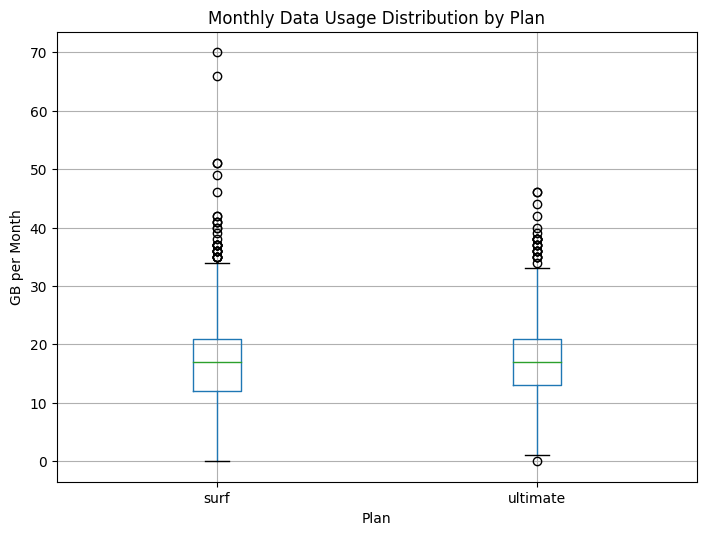

In [42]:
# Boxplot for monthly data usage by plan
user_stats_monthly.boxplot(column='administrative_gb_used_monthly_sum', by='plan', figsize=(8, 6))
plt.title('Monthly Data Usage Distribution by Plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('GB per Month')
plt.show()
# Box = IQR (25th to 75th percentile), line = median, whiskers extend to 1.5*IQR, dots beyond = outliers


**Conclusions on how the users behave in terms of internet consumption relative to plans chosen**

Both Surf and Ultimate users show exceptionally similar data usage patterns, with distributions centered around comparable values. However, Ultimate users tend to use slightly more data on average (17.3 GB vs 16.7 GB). 

The key observation is that Surf users, with only 15 GB included, are far more likely to exceed their limit and incur data overage charges. Ultimate users, with 30 GB included in their selected plan, have more headroom. The standard deviation is comparable between plans, suggesting similar variability in data usage habits. Data overage is the primary revenue driver for Surf plan overages, as $10/GB adds up quickly. Again, it is clear that there are fewer Ultimate users than Surf users, as is to be expected, as not everyone expects themselves to be a power user of the service.

Based on the observed differences in data usage patterns and the relationship to plan limits, there appears to be a meaningful behavioral marker in Surf users being more likely to deal with overage charges that warrants further statistical analysis.


## Revenue

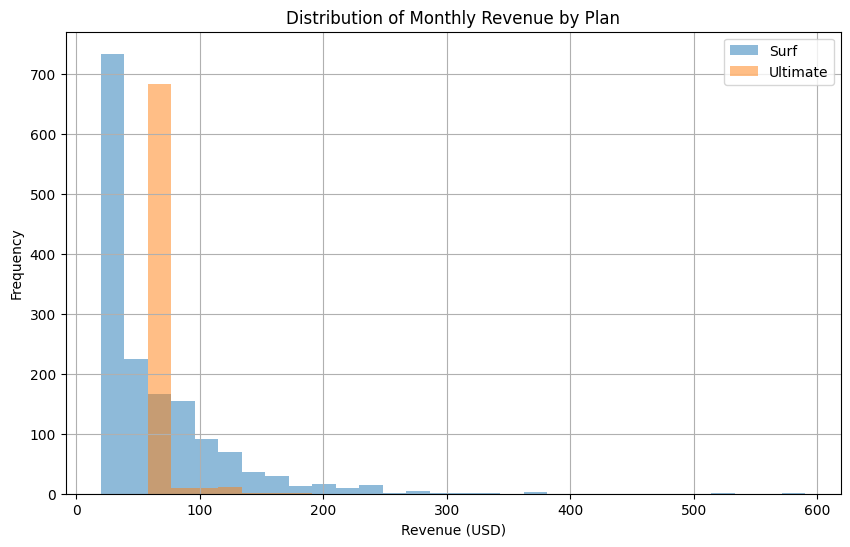

In [43]:
# Compare revenue between plans. Plot a histogram.
surf_revenue = surf_data['revenue']
ultimate_revenue = ultimate_data['revenue']

revenue_by_plan = pd.concat([surf_revenue, ultimate_revenue], axis=1)
revenue_by_plan.columns = ['Surf', 'Ultimate']
revenue_by_plan.plot(kind='hist',
                        bins=30,
                        alpha=0.5,
                        figsize=(10, 6),
                        grid=True,
                        legend=True,
                        title='Distribution of Monthly Revenue by Plan'
    )
plt.xlabel('Revenue (USD)')
plt.ylabel('Frequency')
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

In the Revenue section, consider adding a month-by-month comparison plot (e.g., average revenue per plan by month) to complement the overall histogram/boxplot. This mirrors your calls analysis and can reveal trends across the year.

</div>


In [44]:
# Calculate the mean, variance, and standard deviation of revenue per plan
print('Surf Plan')
print('Mean monthly revenue:', surf_revenue.mean())
print('Variance of monthly revenue:', surf_revenue.var())
print('Std dev of monthly revenue:', surf_revenue.std())
print()
print('Ultimate Plan')
print('Mean monthly revenue:', ultimate_revenue.mean())
print('Variance of monthly revenue:', ultimate_revenue.var())
print('Std dev of monthly revenue:', ultimate_revenue.std())

Surf Plan
Mean monthly revenue: 60.70640813731715
Variance of monthly revenue: 3067.835152293878
Std dev of monthly revenue: 55.388041600095214

Ultimate Plan
Mean monthly revenue: 72.31388888888888
Variance of monthly revenue: 129.8484855509195
Std dev of monthly revenue: 11.395107965742119


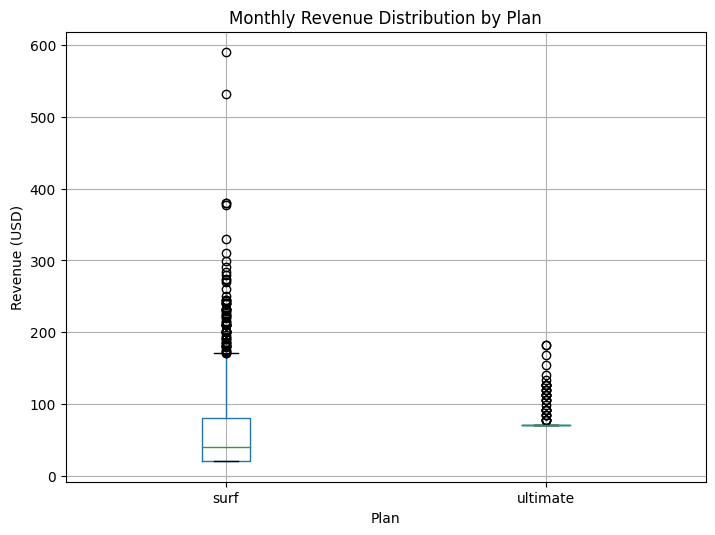

In [45]:
# Boxplot for monthly revenue by plan
user_stats_monthly.boxplot(column='revenue', by='plan', figsize=(8, 6))
plt.title('Monthly Revenue Distribution by Plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Revenue (USD)')
plt.show()
# Box = IQR (25th to 75th percentile), line = median, whiskers extend to 1.5*IQR, dots beyond = outliers

**Conclusions on how the revenue differs based on plans chosen**

The Ultimate plan generates a higher base revenue (70 USD vs 20 USD) per user per month. However, Surf users frequently incur overage charges, especially for data, which can push individual monthly bills well above 20 USD. The revenue distribution for Surf is right-skewed (Mean > Median), indicating that while most Surf users pay close to the base rate, a subset of heavy users generates significantly higher revenue through overages. Ultimate users show a tighter distribution centered near the 70 USD base fee, with far fewer overage charges due to generous plan limits. Despite the higher base fee, Ultimate plan revenue is more predictable while Surf plan revenue is more variable. Once again, it is clear that there are fewer Ultimate users than Surf users, as is to be expected, as not everyone expects themselves to be a power user of the service. However, the greater tendancy of the more numerous Surf users to rack up overage charges warrants further statistical analysis, serving as a potential signal to Megaline to push the Surf plan as the prefered option for new users.

## Test statistical hypotheses

**Hypothesis 1: Average revenue from Ultimate and Surf users differs.**


H0 (Null Hypothesis): The average revenue from Surf users is equal to the average revenue from Ultimate users.

H1 (Alternative Hypothesis): The average revenue from Surf users is NOT equal to the average revenue from Ultimate users.




- Test: Two-sample independent t-test (ttest_ind), two-tailed.
- We use equal_var=False (Welch's t-test) because the revenue variances between plans may differ. User behavior has shown differing variance on multiple fronts when controling for plan selected.
- Alpha = 0.05 is a common measure of statistical significance. This represents a 95% confidence interval, which is a standard in statistical analysis for drawing useful conclusions.



In [46]:

# Test the hypotheses
alpha = 0.05
results = st.ttest_ind(surf_revenue.astype(float), ultimate_revenue.astype(float), equal_var=False) # .astype(float) remediates the following in this operation -  ValueError: data type <class 'numpy.object_'> not inexact
print('surf mean revenue:', surf_revenue.mean())
print('ultimate mean revenue:', ultimate_revenue.mean())
print()
print('p-value:', results.pvalue)
print('Test statistic:', results.statistic) # Dot Bonus Code

"""
For large sample sizes, test statistics with absolute values greater than about ±2 typically indicate statistical significance. A test statistic far from zero is extremely unlikely to occur by chance if there were truly no difference between the groups.
""";

if results.pvalue < alpha:
        print('We reject the null hypothesis: the average revenue from Surf and Ultimate users is significantly different.')
else:
        print('We cannot reject the null hypothesis: there is no significant difference in average revenue between plans.')


surf mean revenue: 60.70640813731715
ultimate mean revenue: 72.31388888888888

p-value: 3.1703905481135734e-15
Test statistic: -7.952094891333888
We reject the null hypothesis: the average revenue from Surf and Ultimate users is significantly different.


**Hypothesis 2: Average revenue from users in the NY-NJ area is different from that of users from other regions.**

H0 (Null Hypothesis): The average revenue from NY-NJ area users is equal to the average revenue from users in other regions.

H1 (Alternative Hypothesis): The average revenue from NY-NJ area users is NOT equal to the average revenue from users in other regions.

- Test: Two-sample independent t-test (ttest_ind), two-tailed.
- We use equal_var=False (Welch's t-test) as a safe assumption in this use case.
- Alpha = 0.05 is a common measure of statistical significance. This represents a 95% confidence interval, which is a standard in statistical analysis for drawing useful conclusions.

In [47]:
# Test the hypotheses
# Comparing NY-NJ area (as one group) against all other regions combined (as the second group)
alpha = 0.05

# Identify NY-NJ users from the city column in the users table
nynj_users = users[users['city'].str.contains('NY-NJ', case=False, na=False)]['user_id'] # This 'NY-NJ' substring was not affected by the mojibake corruption identified in users['city']. I was correct to not deal with trying to correct intrastring dash delimiter discrepancies.

# Split revenue into NY-NJ and other regions
nynj_revenue = user_stats_monthly[user_stats_monthly['user_id'].isin(nynj_users)]['revenue'].astype(float)
other_revenue = user_stats_monthly[~user_stats_monthly['user_id'].isin(nynj_users)]['revenue'].astype(float)

print('NY-NJ users count:', nynj_users.nunique())
print('Other region users count:', users[~users['user_id'].isin(nynj_users)]['user_id'].nunique())
print('NY-NJ mean revenue:', nynj_revenue.mean())
print('Other mean revenue:', other_revenue.mean())
print()

results = st.ttest_ind(nynj_revenue, other_revenue, equal_var=False)

print('p-value:', results.pvalue)
print('Test statistic:', results.statistic) # Dot Bonus Code

if results.pvalue < alpha:
        print('We reject the null hypothesis: the average revenue from NY-NJ users is significantly different from other regions.')
else:
        print('We cannot reject the null hypothesis: there is no significant difference in average revenue between NY-NJ and other regions.')

NY-NJ users count: 80
Other region users count: 420
NY-NJ mean revenue: 59.921352785145885
Other mean revenue: 65.2227713987474

p-value: 0.0335256158853001
Test statistic: -2.1309454999502133
We reject the null hypothesis: the average revenue from NY-NJ users is significantly different from other regions.


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The NY–NJ group selection via `str.contains('NY-NJ')` is likely too narrow for the dataset’s city format (often something like “... NY-NJ-PA MSA”), so it may misclassify users and undermine the hypothesis test. Consider verifying the exact city strings and using a pattern that reliably captures the intended metro area before re-running the test.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well done!

</div>


## General Conclusion

**Data Preparation:**

- Five datasets were loaded and inspected. Date columns in users, calls, messages, and internet were converted to datetime.
- Call durations were rounded up to the nearest minute per Megaline's billing policy (each call rounded individually).
- Monthly internet usage was summed in MB and rounded up to the nearest GB.
- No significant missing-data issues were found beyond churn_date NaN values in users (these represent active customers and were left as-is).

**Assumptions Made:**
           
- 1 GB = 1024 MB for data conversion.
- Individual call durations rounded up before summing (per Megaline policy).
- Monthly data totals rounded up to nearest GB (per Megaline policy).
- Overage charges only apply to usage exceeding the included plan limits (never negative).
- Alpha = 0.05 was chosen as the significance level for both hypothesis tests.
- equal_var=False (Welch's t-test) was used because the variance of revenue between groups may differ.
- NY-NJ users were identified by searching by substring snippet 'NY-NJ'

**User Behavior by Plan:**

- *Calls:* Ultimate users tend to use more minutes on average with greater variability, but both groups generally stay within their included limits.
- *Messages:* Messaging patterns are similar across plans. Surf users are more likely to exceed their 50-message limit than Ultimate users are to exceed their 1,000-message limit.
- *Internet:* Surf users (15 GB included) are far more likely to incur overage charges than Ultimate users (30 GB included), producing a right-skew in Surf revenue.

**Revenue Analysis:**

- *Mean monthly revenue:* Surf: 60.7064 dollars, Ultimate: 72.3139 dollars
- Ultimate users generate higher and more stable revenue due to the 70 dollar base fee; Surf users produce lower base revenue (20 dollars) but heavy Surf users produce overages that create right-skewed revenue distribution.

**Hypothesis Testing and Results:**

- *Hypothesis 1 (NY-NJ vs other regions): Conclusion:* Reject H0. The average revenue from NY-NJ users is statistically significantly different from other regions. Practically, NY-NJ users are generating lower average monthly revenue (about 5.30 dollars less).
- *Hypothesis 2 (Surf vs Ultimate revenue) Conclusion:* Reject H0 strongly. There is overwhelming evidence that average revenue differs between plans; Ultimate users generate significantly more revenue on average.

**Effect Sizes and Practical/Dollar Interpretation:**

- *Absolute monthly difference:* Ultimate − Surf = 72.3139 − 60.7064 = 11.6075 dollars per user per month.
- *Relative difference:* (11.6075 / 60.7064) ≈ 19.1% higher revenue for Ultimate vs Surf.
- *Annualized impact per user:* 11.6075 × 12 ≈ 139.29 dollars additional revenue per Ultimate user per year.
- *NY-NJ regional difference:* (Other regions average ≈ 65.22 dollars) vs (NY-NJ ≈ 59.92 dollars) yields ~5.30/month lower for NY-NJ (approximately 63.60/year lower).

**Statistical Evidence vs Business Significance:**

- *Surf vs Ultimate:* p = 3.17e-15 is extremely small — strong statistical evidence the plans differ in mean revenue. The $11.61 monthly gap is also practically meaningful for acquisition and long-term value modeling.
- *NY-NJ vs others:* p = 0.0335 < 0.05 indicates a statistically significant regional difference; the magnitude (~5.30/month) is business-relevant and worth targeted action.

**Prioritized Business Recommendations:**

- *Acquisition and Advertising Allocation (highest priority):* Prioritize Ultimate in acquisition spend when the objective is to maximize predictable long-term revenue: Ultimate produces ~11.61 dollars more revenue per month (approximately 139/year) per user on average. Suggested tactical move: Reallocate a portion of acquisition budget to campaigns that target profiles most likely to select Ultimate (e.g., larger households, heavy-streaming demographics). Maintain targeted, low-cost upsell campaigns for Surf heavy users: Surf has overage-driven upside; converting frequent overage Surf users to Ultimate or a mid-tier plan could yield net positive in expected value. Actions: usage alerts, trial upgrade offers, “upgrade if you exceed X GB in month” nudges, personalized email/SMS offers.

- *Regional Strategy (NY-NJ focus):* NY-NJ users average ~5.30/month less than other regions. Consider region-specific tactics. For NY-NJ: test messaging that emphasizes value or mid-tier plans that better fit local usage patterns; explore whether NY-NJ has a higher proportion of Surf users or higher churn causing lower ARPU. For other regions: prioritize Ultimate-focused acquisition where revenue is already stronger. Run small regional experiments (split tests) before large budget reallocations.

- *Product & Pricing Adjustments:* Introduce or test a mid-tier plan between Surf and Ultimate (price/feature sweet spot) to capture frequent overage Surf users who won’t pay full Ultimate price. Consider bundled offers or short-term upgrade trials: e.g., offer 1-month Ultimate trial when a Surf user hits overage threshold, then measure conversion/retention.

- *Upsell and Retention Tactics:* Automated usage alerts and preemptive offers when users approach plan limits. Offer discounted upgrade paths for users with repeated overages (identify cohorts with frequent overages). Monitor churn with respect to overage billing; consider “softening” overage shock (e.g., alert + small credit) to reduce churn while preserving some overage revenue.

**Communication-Ready Summary:**

- Ultimate users produce significantly higher revenue than Surf users (mean difference ≈ 11.61/month, p = 3.17e-15), so shifting acquisition toward Ultimate and running targeted upsell campaigns for overage-prone Surf users are high-priority, testable actions. NY-NJ users generate significantly lower revenue than other regions (difference ≈ 5.30/month, p = 0.0335), suggesting the value of region-specific offers and tests.
